# Parking Reservation Chatbot - Phase 1 Test

This notebook tests the LangGraph-based chatbot implementation.

**Features:**
- Intent classification (question vs reservation)
- RAG-based Q&A using Milvus vector store
- Step-by-step reservation data collection
- Conversation state management

## 1. Setup and Imports

In [1]:
import os
import sys
from dotenv import load_dotenv

# Add parent directory to path
sys.path.append(os.path.abspath('..'))

# Load environment variables
load_dotenv()

# Check for OpenAI API key
if not os.getenv('AZURE_OPENAI_API_KEY') and os.getenv('AZURE_OPENAI_ENDPOINT'):
    print("Warning: AZURE_OPENAI_API_KEY or AZURE_OPENAI_ENDPOINT not set!")
    print("Please set it in a .env file in the project root.")
else:
    print("All keys found!")

All keys found!


In [3]:
from chatbot.main import ParkingChatbot
from langchain_core.messages import HumanMessage

## 2. Initialize the Chatbot

In [4]:
chatbot = ParkingChatbot()

Initializing Parking Reservation Chatbot...
✓ Chatbot ready!


## 3. Test RAG-based Q&A

Let's test if the chatbot can answer policy questions using the vector store.

In [5]:
# Test 1: Operating hours
question = "What are your operating hours?"
print(f"🧑 User: {question}")
print(f"\n🤖 Bot: {chatbot.chat(question)}")

🧑 User: What are your operating hours?


/home/tamer/personal-projects/Chatbot-for-Parking-Space-Reservation/.venv/lib/python3.11/site-packages/milvus_lite/__init__.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution



🤖 Bot: Our facility is open 24 hours a day, 7 days a week. However, on-site customer support is available from 8:00 AM to 8:00 PM daily. If you plan to access the facility after 10:00 PM, make sure to scan a valid active reservation QR code or a monthly pass at the pedestrian doors for access. If you need information about real-time availability, please check that directly.


In [6]:
# Test 2: Pricing
question = "How much does parking cost per hour?"
print(f"🧑 User: {question}")
print(f"\n🤖 Bot: {chatbot.chat(question)}")

🧑 User: How much does parking cost per hour?

🤖 Bot: The parking cost is $5.00 per hour (or part thereof). Please check real-time availability for any dynamic adjustments to pricing based on demand.


In [7]:
# Test 3: EV charging
question = "Do you have EV charging stations?"
print(f"🧑 User: {question}")
print(f"\n🤖 Bot: {chatbot.chat(question)}")

🧑 User: Do you have EV charging stations?

🤖 Bot: Yes, we have Level 2 Electric Vehicle charging stations available on **Level 2, Row A**. Currently, there are **2 EV charging spots** available. Standard parking rates apply while you are charging.


In [8]:
# Test 4: Vehicle restrictions
question = "Can I park my RV here?"
print(f"🧑 User: {question}")
print(f"\n🤖 Bot: {chatbot.chat(question)}")

🧑 User: Can I park my RV here?

🤖 Bot: I'm sorry, but RVs are strictly prohibited in this parking facility. We only accept sedans, SUVs, and motorcycles. If you have any other vehicle types, feel free to ask!


In [9]:
# Test 5: Availability
question = "Are there any available spots?"
print(f"🧑 User: {question}")
print(f"\n🤖 Bot: {chatbot.chat(question)}")

🧑 User: Are there any available spots?

🤖 Bot: Yes, there are available spots at SmartPark City Center. Currently, there are 2 accessible spots, 2 spots with EV charging, and 4 standard parking spots available. If you need assistance or have any specific requirements, feel free to ask!


## 4. Test Reservation Flow

Now let's test the step-by-step reservation data collection.

**Note:** Reset the chatbot first to start a fresh conversation.

In [10]:
chatbot.reset()
print("Chatbot conversation reset!")

✓ Conversation reset!
Chatbot conversation reset!


In [11]:
# Step 1: User initiates reservation
message = "I'd like to make a reservation"
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: I'd like to make a reservation

🤖 Bot: I'd be happy to help you with a parking reservation! When would you like to start parking? (Please provide date and time)


In [12]:
# Step 2: Provide start time
message = "I want to start parking tomorrow at 9 AM"
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: I want to start parking tomorrow at 9 AM

🤖 Bot: Great! And when do you plan to leave? (Please provide date and time)


In [13]:
# Step 3: Provide end time
message = "I'll leave at 5 PM"
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: I'll leave at 5 PM

🤖 Bot: Great news! We have parking spots available for your requested time:

📅 Time Slot: 2026-03-26 09:00:00 to 2026-03-26 17:00:00
✅ Available Spots:
  • Accessible: 2 spot(s)
  • EV: 2 spot(s)
  • Standard: 4 spot(s)

To complete your pre-reservation, I'll need a few more details.

What is your full name?


In [14]:
# Step 4: Provide name
message = "My name is John Smith"
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: My name is John Smith

🤖 Bot: Thank you, John Smith! What is your vehicle's license plate number?


In [ ]:
# Step 5: Provide license plate
message = "My license plate is ABC-1234"
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: My license plate is ABC-1234

🤖 Bot: Perfect! I have collected all the information for your pre-reservation:

📋 Pre-Reservation Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👤 Name: John Smith
🚗 License Plate: ABC-1234
📅 Start Time: 2026-03-26 09:00:00
📅 End Time: 2026-03-26 17:00:00
✅ Available Spots:
  • Accessible: 2 spot(s)
  • EV: 2 spot(s)
  • Standard: 4 spot(s)

✅ Status: Awaiting Admin Approval

Your pre-reservation request has been recorded. In the next stage, this information will be sent to our admin team for review and confirmation. You will receive a confirmation once approved.

Is there anything else I can help you with?


I0000 00:00:1774427449.649938   53064 chttp2_transport.cc:1353] unix:/tmp/tmpejdv844r_parking.db.sock: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {http2_error:11, grpc_status:14}
E0000 00:00:1774427449.650324   53064 chttp2_transport.cc:1385] unix:/tmp/tmpejdv844r_parking.db.sock: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 10000ms


## 5. Test Mixed Conversation

Test switching between questions and reservation.

In [14]:
chatbot.reset()
print("Starting mixed conversation test...")

✓ Conversation reset!
Starting mixed conversation test...


In [15]:
# Question first
message = "What's the cancellation policy?"
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: What's the cancellation policy?

🤖 Bot: The cancellation policy states that cancellations made less than 30 minutes before the start time will incur a $5.00 cancellation fee. If you need to cancel your reservation, please ensure you do so at least 30 minutes in advance to avoid this fee. If you have any further questions or need assistance, feel free to ask!


In [16]:
# Then start reservation
message = "I want to book a spot. My name is Jane Doe, license plate XYZ-5678. Tomorrow 2 PM to 6 PM"
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: I want to book a spot. My name is Jane Doe, license plate XYZ-5678. Tomorrow 2 PM to 6 PM

🤖 Bot: Great news! We have parking spots available for your requested time:

📅 Time Slot: 2026-03-17 14:00:00 to 2026-03-17 18:00:00
✅ Available Spots:
  • Accessible: 2 spot(s)
  • EV: 2 spot(s)
  • Standard: 4 spot(s)

To complete your pre-reservation, I'll need a few more details.

What is your full name?


In [17]:
message = "My name is Jane Doe."
print(f"🧑 User: {message}")
print(f"\n🤖 Bot: {chatbot.chat(message)}")

🧑 User: My name is Jane Doe.

🤖 Bot: Perfect! I have collected all the information for your pre-reservation:

📋 Pre-Reservation Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👤 Name: Jane Doe
🚗 License Plate: XYZ-5678
📅 Start Time: 2026-03-17 14:00:00
📅 End Time: 2026-03-17 18:00:00
✅ Available Spots:
  • Accessible: 2 spot(s)
  • EV: 2 spot(s)
  • Standard: 4 spot(s)

✅ Status: Awaiting Admin Approval

Your pre-reservation request has been recorded. In the next stage, this information will be sent to our admin team for review and confirmation. You will receive a confirmation once approved.

Is there anything else I can help you with?


## 6. View Conversation History

In [18]:
history = chatbot.get_conversation_history()

print("="*60)
print("CONVERSATION HISTORY")
print("="*60)

for i, msg in enumerate(history, 1):
    role = "🧑 User" if msg.__class__.__name__ == "HumanMessage" else "🤖 Bot"
    content = msg.content if hasattr(msg, 'content') else str(msg)
    print(f"\n[{i}] {role}:")
    print(content)
    print("-" * 60)

CONVERSATION HISTORY

[1] 🧑 User:
What's the cancellation policy?
------------------------------------------------------------

[2] 🤖 Bot:
The cancellation policy states that cancellations made less than 30 minutes before the start time will incur a $5.00 cancellation fee. If you need to cancel your reservation, please ensure you do so at least 30 minutes in advance to avoid this fee. If you have any further questions or need assistance, feel free to ask!
------------------------------------------------------------

[3] 🧑 User:
I want to book a spot. My name is Jane Doe, license plate XYZ-5678. Tomorrow 2 PM to 6 PM
------------------------------------------------------------

[4] 🤖 Bot:
Great news! We have parking spots available for your requested time:

📅 Time Slot: 2026-03-17 14:00:00 to 2026-03-17 18:00:00
✅ Available Spots:
  • Accessible: 2 spot(s)
  • EV: 2 spot(s)
  • Standard: 4 spot(s)

To complete your pre-reservation, I'll need a few more details.

What is your full name?


## 7. Visualize the Graph (Optional)

If you have graphviz installed, this will show the state graph structure.

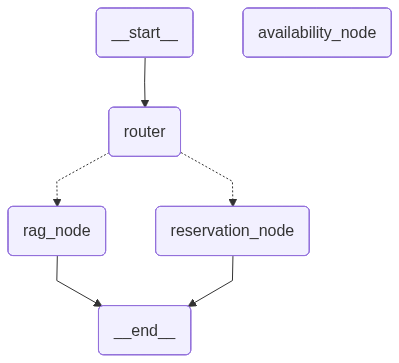

I0000 00:00:1773654013.402307   64868 chttp2_transport.cc:1353] unix:/tmp/tmpv93f0zvx_parking.db.sock: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {grpc_status:14, http2_error:11}
E0000 00:00:1773654013.402434   64868 chttp2_transport.cc:1385] unix:/tmp/tmpv93f0zvx_parking.db.sock: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 10000ms


In [ ]:
try:
    from IPython.display import Image, display
    display(Image(chatbot.app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("Install graphviz if you want to see the visual representation.")

## Summary

✅ **Phase 1 Complete!**

The chatbot can now:
1. **Classify user intent** - Distinguish between questions and reservations
2. **Answer policy questions** - Using RAG with Milvus vector store + reranker
3. **Collect reservation data** - Step-by-step collection of name, car number, and timing
4. **Maintain conversation state** - Using LangGraph's memory system

